# Определение стоимости автомобилей

## Описание проекта
Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Описание данных
Данные находятся в файле /datasets/autos.csv.
Признаки:
* DateCrawled — дата скачивания анкеты из базы
* VehicleType — тип автомобильного кузова
* RegistrationYear — год регистрации автомобиля
* Gearbox — тип коробки передач
* Power — мощность (л. с.)
* Model — модель автомобиля
* Kilometer — пробег (км)
* RegistrationMonth — месяц регистрации автомобиля
* FuelType — тип топлива
* Brand — марка автомобиля
* Repaired — была машина в ремонте или нет
* DateCreated — дата создания анкеты
* NumberOfPictures — количество фотографий автомобиля
* PostalCode — почтовый индекс владельца анкеты (пользователя)
* LastSeen — дата последней активности пользователя

Целевой признак:
* Price — цена (евро)

## Подготовка данных

### Импорт библиотек

In [1]:
!pip install scikit-learn
!pip install catboost
!pip install lightgbm
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor
from catboost import Pool, CatBoostRegressor, cv
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

### Выгрузка и изучение данных

In [2]:
try:
    df = pd.read_csv('autos.csv')
except:
    df = pd.read_csv('/datasets/autos.csv')
display(df.info())
display(df.head())
display(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

None

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

*Промежуточный вывод:* Имеются пропуски в столбцах VehicleType, Gearbox, Model, FuelType, Repaired. Требуется изучить эти столбцы.

*Промежуточный вывод:*  
Оставим значимые факторы:
- VehicleType (тип машины напрямую влияети на её стоимость, так как определяет функциональность)
- Gearbox (налицие автомата или вариатора увеличивает стоимость автомобиля)
- Power (в среднем высокосильная машина обладает большей ценой)
- Model (модель также влияет на стоимость)
- Kilometer (Пробег также влиет на стоимость, чем он выше, тем меньше стоимость)
- FuelType (тип топлива влияет на вид двигателя в авто, что также влияет на цену)
- Brand (чем узнаваемее бренд тем выше стоимость)
- Repaired (наличие дтп в истории авто снижает её стоимость)
- RegistrationYear (влияет на возраст авто, чем он выше тем дешевле оно, если это не ретро авто)

In [3]:
df_1 = df[['VehicleType', 'Gearbox', 'Power','Kilometer','FuelType','Brand',
                         'Repaired', 'RegistrationYear', 'Model','Price']]
display(df_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   VehicleType       316879 non-null  object
 1   Gearbox           334536 non-null  object
 2   Power             354369 non-null  int64 
 3   Kilometer         354369 non-null  int64 
 4   FuelType          321474 non-null  object
 5   Brand             354369 non-null  object
 6   Repaired          283215 non-null  object
 7   RegistrationYear  354369 non-null  int64 
 8   Model             334664 non-null  object
 9   Price             354369 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 27.0+ MB


None

*Промежуточный вывод:*
- VehicleType (заполним пропуски по популярному типу)
- Gearbox (NaN заполним механикой)
- Model (для NaN заполним 'unknown')
- Power (Скоректируем значение, уберём очень низкие и очень высокие)
- FuelType (заполним пропуски по популярному типу)
- Repaired (для NaN заполним 'no')
- RegistrationYear (проверим на корректность)
- Price (уберём аномальные значения)

### Предобработка данных

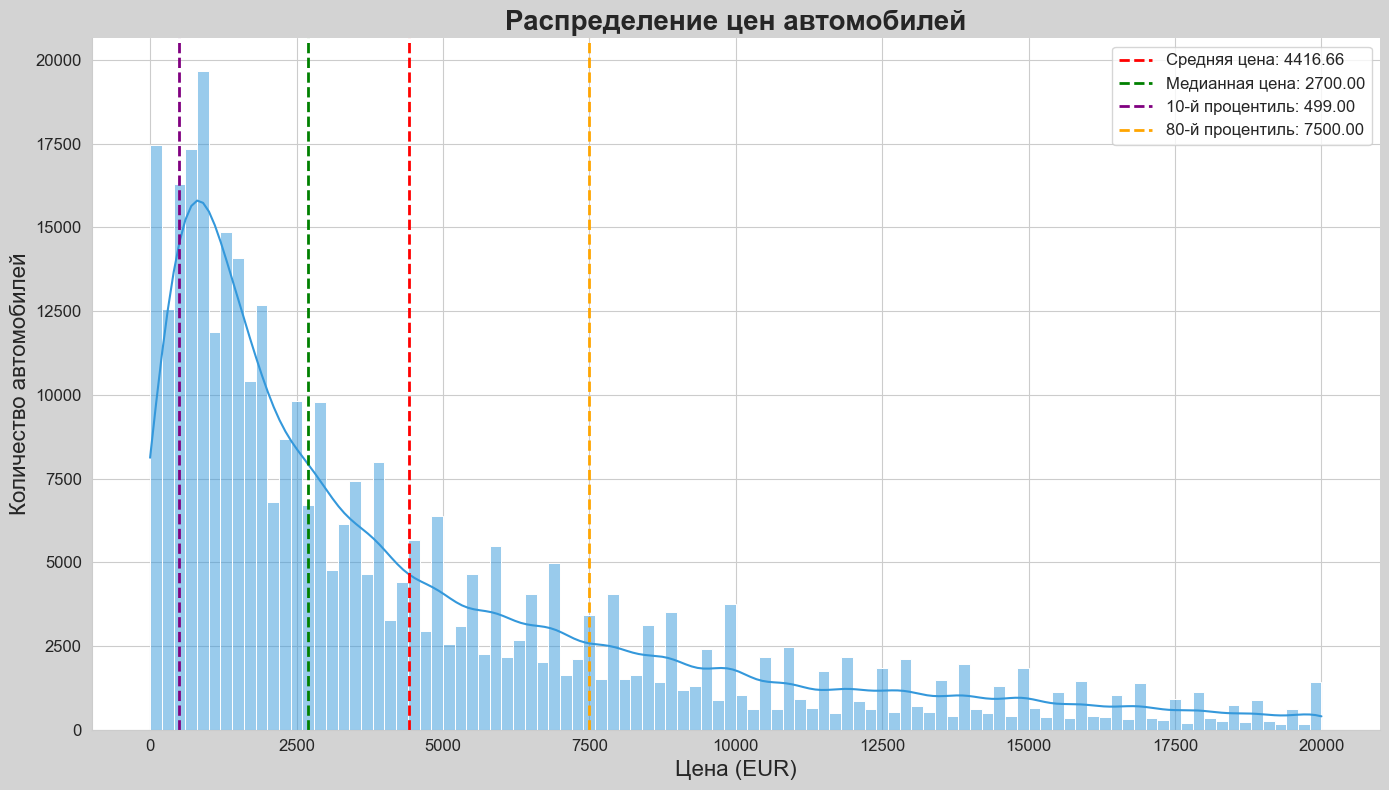

In [4]:
sns.set_style("whitegrid") 
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'lightgray'

plt.figure(figsize=(14, 8)) 
sns.histplot(df_1['Price'], bins=100, kde=True, color="#3498db") 
plt.title('Распределение цен автомобилей', fontsize=20, fontweight='bold')
plt.xlabel('Цена (EUR)', fontsize=16)
plt.ylabel('Количество автомобилей', fontsize=16)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(['Распределение цен'], fontsize=14)
sns.despine()
mean_price = df_1['Price'].mean()
median_price = df_1['Price'].median()
std_price = df_1['Price'].std()
quantile_10 = df_1['Price'].quantile(0.1)
quantile_80 = df_1['Price'].quantile(0.8)

plt.axvline(mean_price, color='red', linestyle='dashed', linewidth=2, label=f'Средняя цена: {mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='dashed', linewidth=2, label=f'Медианная цена: {median_price:.2f}')
plt.axvline(quantile_10, color='purple', linestyle='dashed', linewidth=2, label=f'10-й процентиль: {quantile_10:.2f}')
plt.axvline(quantile_80, color='orange', linestyle='dashed', linewidth=2, label=f'80-й процентиль: {quantile_80:.2f}')
plt.legend(fontsize=12)

plt.tight_layout() 
plt.show()

*Промежуточный вывод:*  
* Средняя цена автомобиля в датасете 4417 евро, медианная 2700 евро.
* Для объективности исследования уберём слишком маленькие значение и слишком большие (в больших значениях наблюдаются выбросы).
* Границами датасета обозначим 10-й процентиль (499 евро) и 80-й процентиль (7500 евро).

In [5]:
df_1 = df_1.query('499 <= Price <= 7800')
display(df_1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 250756 entries, 3 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   VehicleType       226182 non-null  object
 1   Gearbox           238566 non-null  object
 2   Power             250756 non-null  int64 
 3   Kilometer         250756 non-null  int64 
 4   FuelType          229698 non-null  object
 5   Brand             250756 non-null  object
 6   Repaired          201701 non-null  object
 7   RegistrationYear  250756 non-null  int64 
 8   Model             238213 non-null  object
 9   Price             250756 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 21.0+ MB


None

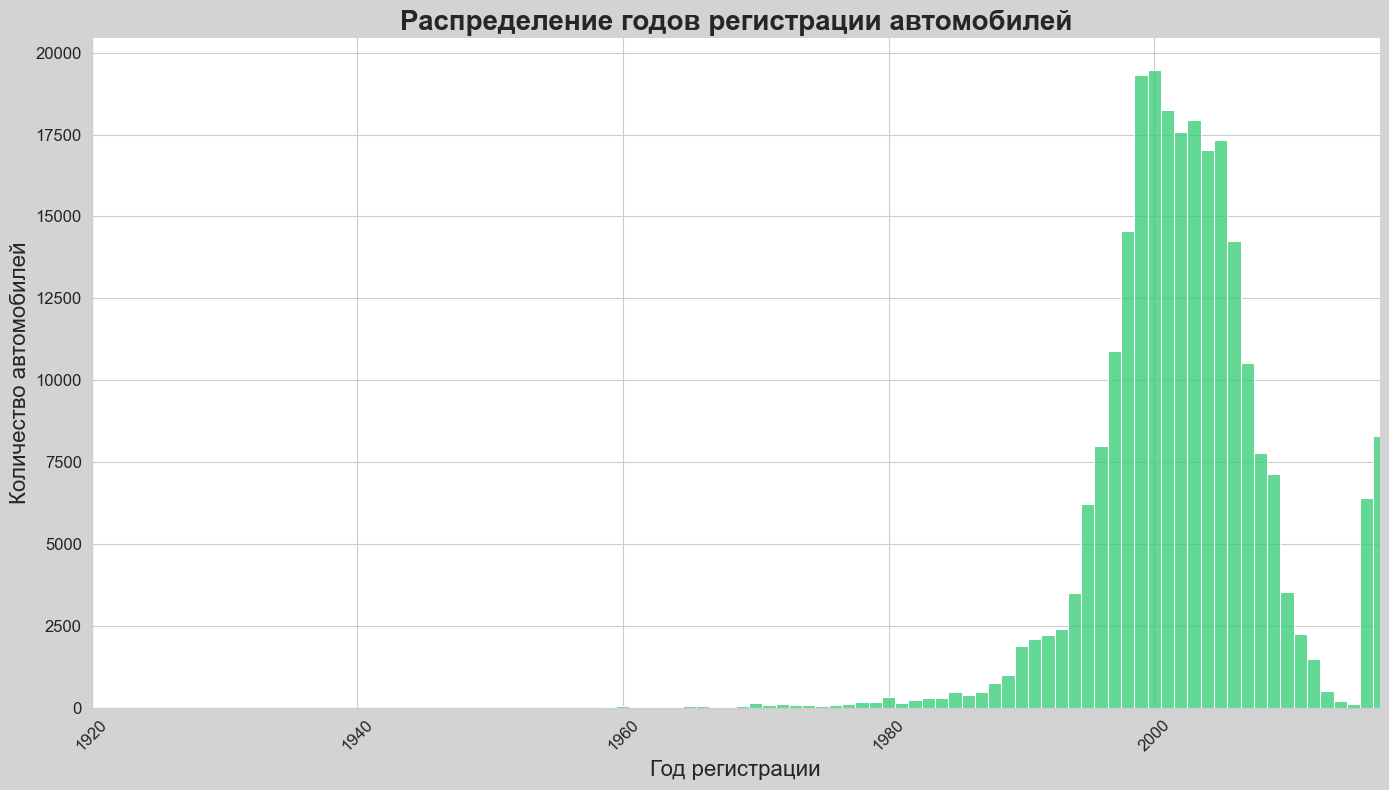

In [6]:
date = pd.to_datetime(df['DateCrawled'])
left_bound = 1920
right_bound = date.max().year + 1   

df_1 = df_1[(df_1['RegistrationYear'] >= left_bound) &
                                          (df_1['RegistrationYear'] <= right_bound)]

sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'lightgray'

plt.figure(figsize=(14, 8))
sns.histplot(df_1['RegistrationYear'], bins=right_bound - left_bound + 1, kde=False, color="#2ecc71", discrete=True) 

plt.title('Распределение годов регистрации автомобилей', fontsize=20, fontweight='bold')
plt.xlabel('Год регистрации', fontsize=16)
plt.ylabel('Количество автомобилей', fontsize=16)


plt.xticks(fontsize=12, rotation=45)  
plt.yticks(fontsize=12)

plt.xlim(left_bound, right_bound)

sns.despine()

plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Левую границу можно сдвинуть до 1960.

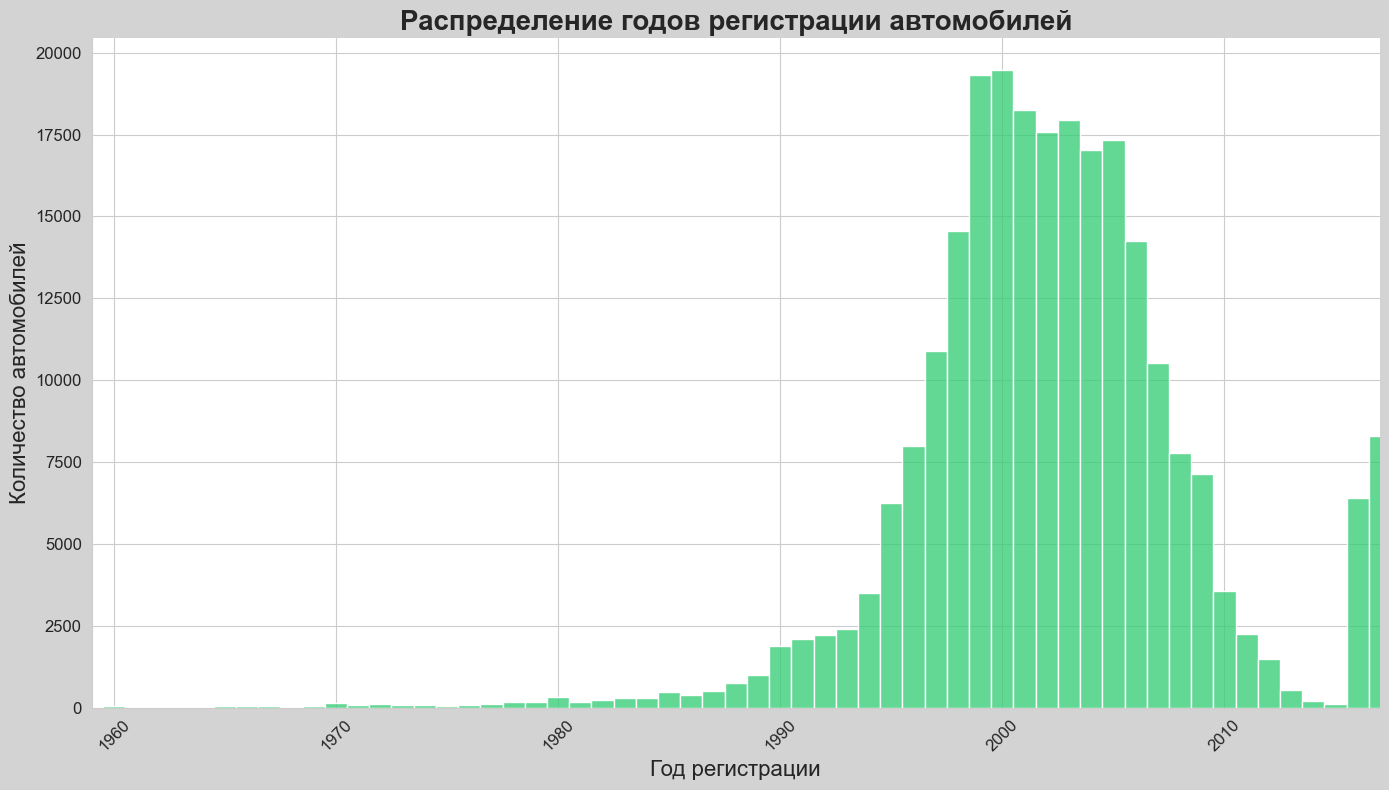

In [7]:
date = pd.to_datetime(df['DateCrawled'])
left_bound = 1959
right_bound = date.max().year + 1   

df_1 = df_1[(df_1['RegistrationYear'] >= left_bound) &
                                          (df_1['RegistrationYear'] <= right_bound)]

sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'lightgray'

plt.figure(figsize=(14, 8))
sns.histplot(df_1['RegistrationYear'], bins=right_bound - left_bound + 1, kde=False, color="#2ecc71", discrete=True) 

plt.title('Распределение годов регистрации автомобилей', fontsize=20, fontweight='bold')
plt.xlabel('Год регистрации', fontsize=16)
plt.ylabel('Количество автомобилей', fontsize=16)


plt.xticks(fontsize=12, rotation=45)  
plt.yticks(fontsize=12)

plt.xlim(left_bound, right_bound)

sns.despine()

plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Были выставлены границы по году регистрации от 1960 до 2016.

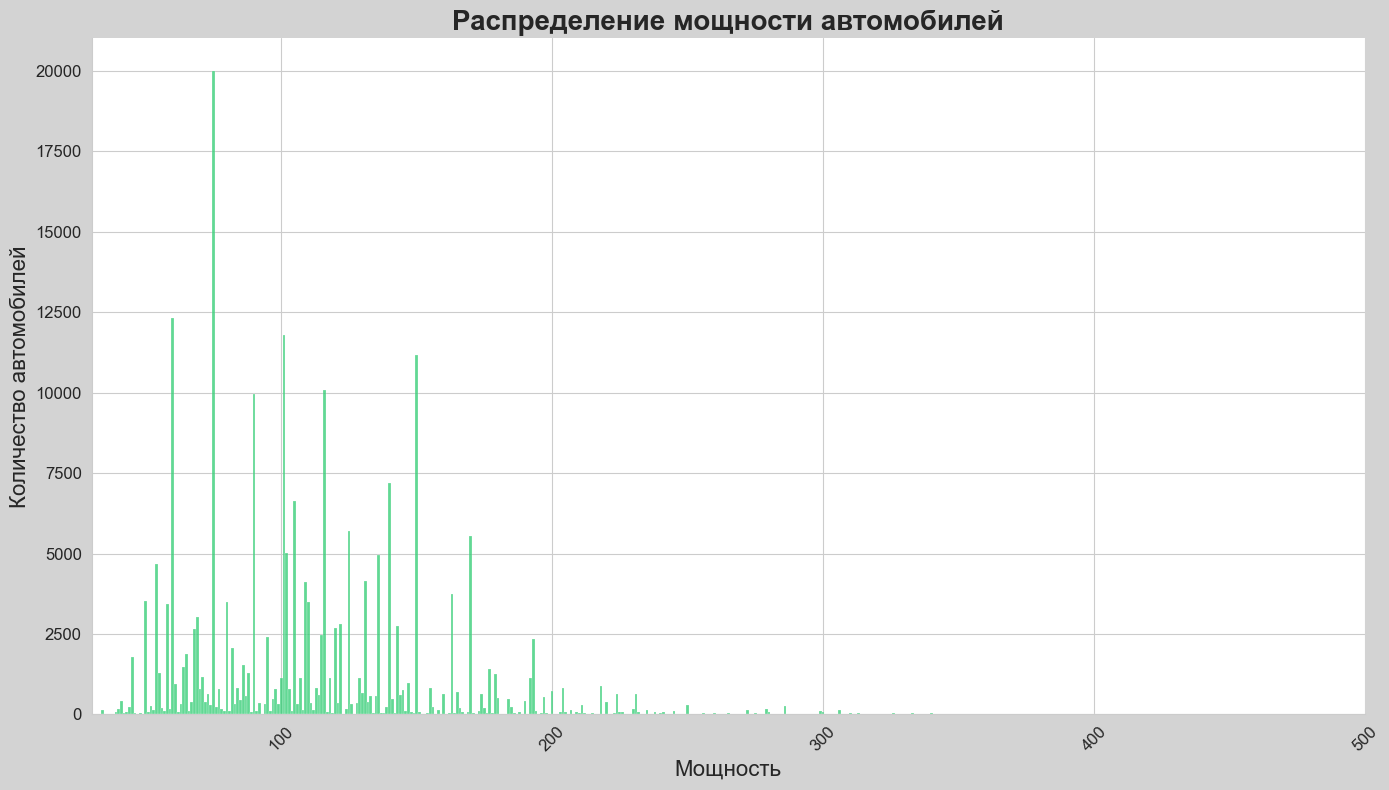

In [8]:
left_bound = 30
right_bound = 500  

df_1 = df_1[(df_1['Power'] >= left_bound) &
                                          (df_1['Power'] <= right_bound)]

sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'lightgray'

plt.figure(figsize=(14, 8))
sns.histplot(df_1['Power'], bins=right_bound - left_bound + 1, kde=False, color="#2ecc71", discrete=True) 

plt.title('Распределение мощности автомобилей', fontsize=20, fontweight='bold')
plt.xlabel('Мощность', fontsize=16)
plt.ylabel('Количество автомобилей', fontsize=16)


plt.xticks(fontsize=12, rotation=45)  
plt.yticks(fontsize=12)

plt.xlim(left_bound, right_bound)

sns.despine()

plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Верхнюю границу мощности можно сместить ещё ниже.

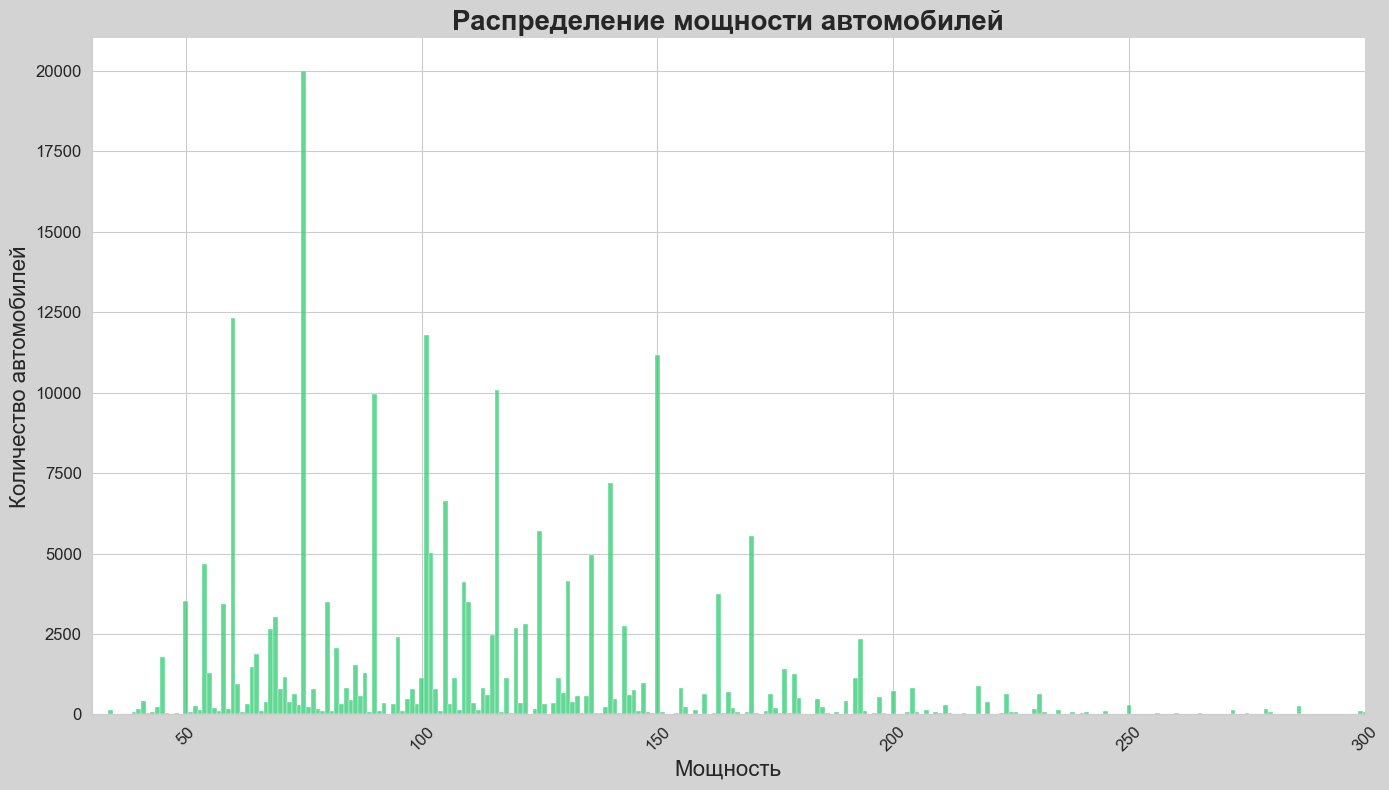

In [9]:
left_bound = 30
right_bound = 300  

df_1 = df_1[(df_1['Power'] >= left_bound) &
                                          (df_1['Power'] <= right_bound)]

sns.set_style("whitegrid")
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'lightgray'

plt.figure(figsize=(14, 8))
sns.histplot(df_1['Power'], bins=right_bound - left_bound + 1, kde=False, color="#2ecc71", discrete=True) 

plt.title('Распределение мощности автомобилей', fontsize=20, fontweight='bold')
plt.xlabel('Мощность', fontsize=16)
plt.ylabel('Количество автомобилей', fontsize=16)


plt.xticks(fontsize=12, rotation=45)  
plt.yticks(fontsize=12)

plt.xlim(left_bound, right_bound)

sns.despine()

plt.tight_layout()
plt.show()

*Промежуточный вывод:*  
Границы мощности автомобилей выставлены от 30 до 300 лошадиных сил.

In [10]:
df_1.fillna({'Gearbox':'manual', 'Repaired':'no', 'Model':'unknown'}, inplace=True)
df_1.isna().sum()

VehicleType         13769
Gearbox                 0
Power                   0
Kilometer               0
FuelType            13788
Brand                   0
Repaired                0
RegistrationYear        0
Model                   0
Price                   0
dtype: int64

*Промежуточный вывод:*  
Были произведены замены пропусков в столбцах Gearbox, Repaired, Model.

In [11]:
vehicle_type_pivot_table = df_1.pivot_table(
    index=['VehicleType'],
    columns=['Brand'],
    values=['Price'],
    aggfunc=['count']
)

display("Исходная сводная таблица типов транспортных средств:")
display(vehicle_type_pivot_table)

vehicle_type_pivot_table = vehicle_type_pivot_table['count']['Price']

display("\nСводная таблица типов транспортных средств - только количества:")
display(vehicle_type_pivot_table)

df_1['VehicleType'].fillna(0, inplace=True)


def fillna_by_brand(row, vehicle_type_pivot_table):
    """
    Заполняет пропущенные значения 'VehicleType' на основе наиболее часто встречающегося типа для данного бренда.
    """
    brand = row['Brand']
    vehicle_type = row['VehicleType']  

    if pd.isna(vehicle_type) or vehicle_type == 0:  
        if brand in vehicle_type_pivot_table.columns: 
            try:
                fill_value = vehicle_type_pivot_table[brand].idxmax() 
            except ValueError:  
                fill_value = 'unknown'  
        else:
            fill_value = 'unknown' 
    else:
        fill_value = vehicle_type  

    return fill_value


df_1['VehicleType'] = df_1.apply(fillna_by_brand, args=(vehicle_type_pivot_table,), axis=1)

display("\nКоличество оставшихся значений NaN в 'VehicleType':", df_1['VehicleType'].isna().sum())

display("\nКоличество значений для заполненного 'VehicleType':")
display(df_1['VehicleType'].value_counts())

'Исходная сводная таблица типов транспортных средств:'

count                                                     \
                 Price                                                      
Brand       alfa_romeo    audi      bmw chevrolet chrysler citroen  dacia   
VehicleType                                                                 
bus                NaN     9.0      2.0      91.0    321.0   938.0   12.0   
convertible      103.0   643.0   1523.0       6.0    176.0    75.0    NaN   
coupe            170.0   603.0   2350.0      38.0     14.0   116.0    NaN   
other              7.0    69.0    163.0      14.0      4.0    78.0    5.0   
sedan            708.0  6956.0  10339.0     127.0    178.0   483.0   92.0   
small            163.0   754.0    271.0     517.0     10.0  1206.0  172.0   
suv                NaN    14.0    140.0     126.0      8.0     7.0   43.0   
wagon            360.0  5931.0   4629.0      77.0    176.0   440.0  205.0   

                                     ...                          \
                                     ...                           
Brand       daewoo daihatsu    fiat  ...    seat   skoda   smart   
VehicleType                          ...                           
bus           23.0     28.0   629.0  ...   464.0   153.0     NaN   
convertible    1.0      8.0   220.0  ...     NaN     3.0   927.0   
coupe          2.0      NaN   131.0  ...    59.0     4.0   277.0   
other          3.0      3.0   116.0  ...    36.0    17.0     3.0   
sedan         75.0     30.0   702.0  ...  1127.0   611.0    26.0   
small        188.0    358.0  3780.0  ...  2350.0   870.0  2843.0   
suv            1.0     41.0    16.0  ...     1.0     6.0     NaN   
wagon         33.0     14.0   305.0  ...   183.0  1629.0     9.0   

                                                                             
                                                                             
Brand       sonstige_autos subaru suzuki  toyota trabant volkswagen   volvo  
VehicleType                                                                  
bus                  102.0   13.0   23.0   319.0     NaN     5411.0     NaN  
convertible          134.0    NaN   25.0    45.0     NaN     1866.0    32.0  
coupe                 59.0    3.0    2.0   156.0     1.0      631.0    49.0  
other                 40.0    4.0    7.0    12.0     NaN      501.0     NaN  
sedan                173.0   92.0  116.0   685.0     9.0    13509.0   460.0  
small                 55.0   84.0  725.0  1340.0     3.0    13267.0     5.0  
suv                  129.0   38.0  505.0   231.0     NaN      177.0    28.0  
wagon                 80.0  218.0   71.0   416.0     7.0     8690.0  1476.0  

[8 rows x 40 columns]

'\nСводная таблица типов транспортных средств - только количества:'

Brand,alfa_romeo,audi,bmw,chevrolet,chrysler,citroen,dacia,daewoo,daihatsu,fiat,...,seat,skoda,smart,sonstige_autos,subaru,suzuki,toyota,trabant,volkswagen,volvo
VehicleType,,,,,,,,,,,,,,,,,,,,,
bus,NaN,9.0,2.0,91.0,321.0,938.0,12.0,23.0,28.0,629.0,...,464.0,153.0,NaN,102.0,13.0,23.0,319.0,NaN,5411.0,NaN
convertible,103.0,643.0,1523.0,6.0,176.0,75.0,NaN,1.0,8.0,220.0,...,NaN,3.0,927.0,134.0,NaN,25.0,45.0,NaN,1866.0,32.0
coupe,170.0,603.0,2350.0,38.0,14.0,116.0,NaN,2.0,NaN,131.0,...,59.0,4.0,277.0,59.0,3.0,2.0,156.0,1.0,631.0,49.0
other,7.0,69.0,163.0,14.0,4.0,78.0,5.0,3.0,3.0,116.0,...,36.0,17.0,3.0,40.0,4.0,7.0,12.0,NaN,501.0,NaN
sedan,708.0,6956.0,10339.0,127.0,178.0,483.0,92.0,75.0,30.0,702.0,...,1127.0,611.0,26.0,173.0,92.0,116.0,685.0,9.0,13509.0,460.0
small,163.0,754.0,271.0,517.0,10.0,1206.0,172.0,188.0,358.0,3780.0,...,2350.0,870.0,2843.0,55.0,84.0,725.0,1340.0,3.0,13267.0,5.0
suv,NaN,14.0,140.0,126.0,8.0,7.0,43.0,1.0,41.0,16.0,...,1.0,6.0,NaN,129.0,38.0,505.0,231.0,NaN,177.0,28.0
wagon,360.0,5931.0,4629.0,77.0,176.0,440.0,205.0,33.0,14.0,305.0,...,183.0,1629.0,9.0,80.0,218.0,71.0,416.0,7.0,8690.0,1476.0


"\nКоличество оставшихся значений NaN в 'VehicleType':"

np.int64(0)

"\nКоличество значений для заполненного 'VehicleType':"

VehicleType
sedan          67969
small          63119
wagon          42619
bus            19122
convertible    11705
coupe           9238
suv             4643
other           1859
Name: count, dtype: int64

In [12]:
fuel_type_pivot_table = df_1.pivot_table(
    index=['FuelType'],
    columns=['Brand'],
    values=['Price'],
    aggfunc=['count']
)

fuel_type_pivot_table = fuel_type_pivot_table['count']['Price']
df_1['FuelType'].fillna(0, inplace=True)

df_1['FuelType'] = df_1.apply(fillna_by_brand, args=(fuel_type_pivot_table,), axis=1)

display("\nКоличество оставшихся значений NaN в 'FuelType':", df_1['FuelType'].isna().sum())

display("\nКоличество значений для заполненного 'FuelType':")
display(df_1['FuelType'].value_counts())

"\nКоличество оставшихся значений NaN в 'FuelType':"

np.int64(0)

"\nКоличество значений для заполненного 'FuelType':"

FuelType
sedan          67969
small          63119
wagon          42619
bus            19122
convertible    11705
coupe           9238
suv             4643
other           1859
Name: count, dtype: int64

In [13]:
df_1.isna().sum()

VehicleType         0
Gearbox             0
Power               0
Kilometer           0
FuelType            0
Brand               0
Repaired            0
RegistrationYear    0
Model               0
Price               0
dtype: int64

*Промежуточный вывод:*  
Были произведены замены пропусков в столбцах VehicleType и FuelType на самый популярный тип по бренду.

In [14]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220274 entries, 3 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   VehicleType       220274 non-null  object
 1   Gearbox           220274 non-null  object
 2   Power             220274 non-null  int64 
 3   Kilometer         220274 non-null  int64 
 4   FuelType          220274 non-null  object
 5   Brand             220274 non-null  object
 6   Repaired          220274 non-null  object
 7   RegistrationYear  220274 non-null  int64 
 8   Model             220274 non-null  object
 9   Price             220274 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 18.5+ MB


*Промежуточный вывод:*  
* Gearbox и Repaired должны иметь тип булево
* Создам столбец Manual, где 1 это в машине коробка механика, а 0 вариатор или автомат.
* Создам столбец repaired, где 1 это был ремонт в машине, 0 не был.

In [15]:
def is_manual(gearbox):
    if pd.isna(gearbox):
        return 0 
    return 1 if gearbox.lower() == 'manual' else 0  

df_1['Manual'] = df_1['Gearbox'].apply(is_manual)

display("Распределение значений в столбце 'Manual':")
display(df_1['Manual'].value_counts())

display("Распределение значений в столбце 'Gearbox':")
display(df_1['Gearbox'].value_counts())

"Распределение значений в столбце 'Manual':"

Manual
1    185624
0     34650
Name: count, dtype: int64

"Распределение значений в столбце 'Gearbox':"

Gearbox
manual    185624
auto       34650
Name: count, dtype: int64

In [16]:
def is_repaired(repaired):
    if pd.isna(repaired):
        return 0 
    return 1 if repaired.lower() == 'yes' else 0  

df_1['repaired'] = df_1['Repaired'].apply(is_repaired)

display("Распределение значений в столбце 'repaired':")
display(df_1['repaired'].value_counts())

display("Распределение значений в столбце 'Repaired':")
display(df_1['Repaired'].value_counts())

"Распределение значений в столбце 'repaired':"

repaired
0    198176
1     22098
Name: count, dtype: int64

"Распределение значений в столбце 'Repaired':"

Repaired
no     198176
yes     22098
Name: count, dtype: int64

In [17]:
df_1.drop(['Repaired','Gearbox'], inplace=True, axis=1)

In [18]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 220274 entries, 3 to 354368
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   VehicleType       220274 non-null  object
 1   Power             220274 non-null  int64 
 2   Kilometer         220274 non-null  int64 
 3   FuelType          220274 non-null  object
 4   Brand             220274 non-null  object
 5   RegistrationYear  220274 non-null  int64 
 6   Model             220274 non-null  object
 7   Price             220274 non-null  int64 
 8   Manual            220274 non-null  int64 
 9   repaired          220274 non-null  int64 
dtypes: int64(6), object(4)
memory usage: 18.5+ MB


In [19]:
duplicates = df_1.duplicated()
display(df_1[duplicates])
display(f"Количество дубликатов: {duplicates.sum()}")

,VehicleType,Power,Kilometer,FuelType,Brand,RegistrationYear,Model,Price,Manual,repaired
1017,small,45,70000,small,opel,1996,corsa,500,1,0
1117,small,60,150000,small,volkswagen,1999,polo,950,1,0
2833,small,58,150000,small,opel,2001,corsa,1499,1,0
3551,sedan,75,150000,sedan,volkswagen,1999,golf,1670,1,0
3786,sedan,101,150000,sedan,volkswagen,2002,golf,2999,1,0
...,...,...,...,...,...,...,...,...,...,...
354344,wagon,125,150000,wagon,audi,1998,a4,1600,1,0
354348,sedan,105,150000,sedan,volkswagen,2006,golf,5900,1,0
354352,sedan,145,150000,sedan,mercedes_benz,2003,e_klasse,6500,0,0
354355,sedan,105,150000,sedan,seat,2008,leon,4400,1,0


'Количество дубликатов: 40261'

*Промежуточный вывод:*  
Уберём дубликаты, так как наличие дубликатов в тренировочной и тестовой выборках может привести к завышенной оценке производительности модели, поскольку модель уже "видела" эти примеры во время обучения.

In [20]:
df_1 = df_1.drop_duplicates()
display(f"Размер DataFrame после удаления дубликатов: {len(df_1)}")

'Размер DataFrame после удаления дубликатов: 180013'

**Вывод:**
* Были импортированы библиотеки и изучены данные;
* Были выведены пропущенные значения и устранены или заменены;
* Были удалены выбросы и аномальные значения;
* Также были измены типы двух столбцов;
* Были удалены дубликаты.

## Обучение моделей

Выберем следующие алгоритмы для обучения модели:
* LinearRegression
* Ridge
* DecisionTreeRegressor
* CatBoostRegressor
* LGBMRegressor

In [21]:
# Разделение признаков и целевой переменной
target = df_1['Price']
original_features = df_1.drop('Price', axis=1)

# Разбиение на обучающую и тестовую выборки (без кодирования)
original_features_train, original_features_test, target_train, target_test = train_test_split(
    original_features, target, test_size=0.25, random_state=19072020
)

# 2. Ordinal Encoding

# Определение категориальных столбцов
cat_columns = ['VehicleType','FuelType','Brand','Model']

# Создание и обучение OrdinalEncoder с обработкой неизвестных значений
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(original_features_train[cat_columns]) 

# Кодирование категориальных признаков в train и test
ordinal_features_train = original_features_train.copy()
ordinal_features_test = original_features_test.copy()

ordinal_features_train[cat_columns] = encoder.transform(ordinal_features_train[cat_columns])
ordinal_features_test[cat_columns] = encoder.transform(ordinal_features_test[cat_columns])



# 3. One-Hot Encoding

# OHE кодирование для train и test по отдельности, используя общие столбцы, найденные в train
ohe_features_train = pd.get_dummies(original_features_train, drop_first=True)
ohe_features_test = pd.get_dummies(original_features_test, drop_first=True)

# Выравнивание столбцов после OHE, добавление отсутствующих
common_columns = list(ohe_features_train.columns.intersection(ohe_features_test.columns))

for col in ohe_features_train.columns:
    if col not in common_columns:
        ohe_features_test[col] = 0
for col in ohe_features_test.columns:
    if col not in common_columns:
        ohe_features_train[col] = 0

ohe_features_train = ohe_features_train[common_columns]
ohe_features_test = ohe_features_test[common_columns]

### LinearRegression

In [22]:
regressor = LinearRegression()

display("# Оценка модели LinearRegression (RMSE) с использованием кросс-валидации")

start_time_train = time.time()  

cv_results = cross_val_score(regressor,
                              ohe_features_train,
                              target_train,
                              cv=5,
                              scoring='neg_mean_squared_error')

end_time_train = time.time()  
training_time_cv = end_time_train - start_time_train

rmse_scores = np.sqrt(-cv_results)
cv_RMSE_LR = rmse_scores.mean()

display(f"Среднее RMSE от кросс-валидации LinearRegression = {cv_RMSE_LR:.4f}")
display(f"Время обучения модели LinearRegression (кросс-валидация): {training_time_cv:.4f} секунд")

start_time_fit = time.time()
regressor.fit(ohe_features_train, target_train)
end_time_fit = time.time()
training_time_fit = end_time_fit - start_time_fit

start_time_predict = time.time()
predictions = regressor.predict(ohe_features_train)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict

display(f"Время обучения модели LinearRegression (fit): {training_time_fit:.4f} секунд")
display(f"Время предсказания модели LinearRegression: {prediction_time:.4f} секунд")

'# Оценка модели LinearRegression (RMSE) с использованием кросс-валидации'

'Среднее RMSE от кросс-валидации LinearRegression = 1463.3303'

'Время обучения модели LinearRegression (кросс-валидация): 8.9166 секунд'

'Время обучения модели LinearRegression (fit): 2.0733 секунд'

'Время предсказания модели LinearRegression: 0.3159 секунд'

### Ridge

In [23]:
regressor = Ridge()

hyperparams = {'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg']}

display("# Настройка гиперпараметров для Ridge (RMSE)")

start_time_cv = time.time() 

grid_search = GridSearchCV(regressor,
                           hyperparams,
                           scoring='neg_mean_squared_error',
                           cv=5)
grid_search.fit(ohe_features_train, target_train)

end_time_cv = time.time()
training_time_cv = end_time_cv - start_time_cv

display("Найдены лучшие параметры:")
display(grid_search.best_params_)

display("Результаты кросс-валидации (RMSE):")
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
params = grid_search.cv_results_['params']

for mean, std, param in zip(means, stds, params):
    rmse = np.sqrt(-mean)
    display(f"{rmse:.6f} +/- {std:.3f} для {param}")

cv_RMSE_R = np.sqrt(-grid_search.best_score_)
display(f"Среднее RMSE для лучшего результата: {cv_RMSE_R:.4f}")
display(f"Время обучения модели Ridge (с GridSearchCV): {training_time_cv:.4f} секунд")

start_time_fit = time.time()
best_ridge_model = grid_search.best_estimator_
best_ridge_model.fit(ohe_features_train, target_train) 
end_time_fit = time.time()
training_time_fit = end_time_fit - start_time_fit

start_time_predict = time.time()
predictions = best_ridge_model.predict(ohe_features_train)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict

display(f"Время обучения модели Ridge (с лучшими параметрами): {training_time_fit:.4f} секунд")
display(f"Время предсказания модели Ridge (с лучшими параметрами): {prediction_time:.4f} секунд")

'# Настройка гиперпараметров для Ridge (RMSE)'

'Найдены лучшие параметры:'

{'solver': 'svd'}

'Результаты кросс-валидации (RMSE):'

"1463.166111 +/- 21221.358 для {'solver': 'auto'}"

...

"1672.806616 +/- 28271.739 для {'solver': 'sparse_cg'}"

'Среднее RMSE для лучшего результата: 1463.1661'

'Время обучения модели Ridge (с GridSearchCV): 30.6408 секунд'

'Время обучения модели Ridge (с лучшими параметрами): 3.8575 секунд'

'Время предсказания модели Ridge (с лучшими параметрами): 0.3584 секунд'

### DecisionTreeRegressor

In [24]:
regressor = DecisionTreeRegressor()

max_depth_list = list(range(2, 31))
hyperparams = {'criterion': ['squared_error'],
               'max_depth': max_depth_list,
               'random_state': [42]}

display("# Настройка гиперпараметров для DecisionTreeRegressor (RMSE)")

start_time_cv = time.time()  

grid_search = GridSearchCV(regressor,
                           hyperparams,
                           scoring='neg_mean_squared_error',
                           cv=5)
grid_search.fit(ordinal_features_train, target_train)

end_time_cv = time.time()
training_time_cv = end_time_cv - start_time_cv

display("Найдены лучшие параметры:")
display(grid_search.best_params_)

display("Результаты кросс-валидации (RMSE):")
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
params = grid_search.cv_results_['params']

for mean, std, param in zip(means, stds, params):
    rmse = np.sqrt(-mean)
    display(f"{rmse:.6f} +/- {std:.3f} для {param}")

cv_RMSE_DTR_ordinal = np.sqrt(-grid_search.best_score_)
display(f"Среднее RMSE для лучшей модели: {cv_RMSE_DTR_ordinal:.4f}")
display(f"Время обучения DecisionTreeRegressor (с GridSearchCV): {training_time_cv:.4f} секунд")


start_time_fit = time.time()
best_dtr_model = grid_search.best_estimator_  
best_dtr_model.fit(ordinal_features_train, target_train) 
end_time_fit = time.time()
training_time_fit = end_time_fit - start_time_fit

start_time_predict = time.time()
predictions = best_dtr_model.predict(ordinal_features_train)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict

display(f"Время обучения DecisionTreeRegressor (с лучшими параметрами): {training_time_fit:.4f} секунд")
display(f"Время предсказания DecisionTreeRegressor (с лучшими параметрами): {prediction_time:.4f} секунд")

'# Настройка гиперпараметров для DecisionTreeRegressor (RMSE)'

'Найдены лучшие параметры:'

{'criterion': 'squared_error', 'max_depth': 13, 'random_state': 42}

'Результаты кросс-валидации (RMSE):'

"1590.263465 +/- 13169.814 для {'criterion': 'squared_error', 'max_depth': 2, 'random_state': 42}"

...

"1216.448133 +/- 14120.367 для {'criterion': 'squared_error', 'max_depth': 30, 'random_state': 42}"

'Среднее RMSE для лучшей модели: 1122.8416'

'Время обучения DecisionTreeRegressor (с GridSearchCV): 37.5267 секунд'

'Время обучения DecisionTreeRegressor (с лучшими параметрами): 0.2610 секунд'

'Время предсказания DecisionTreeRegressor (с лучшими параметрами): 0.0240 секунд'

### CatBoostRegressor

In [25]:
regressor = CatBoostRegressor(learning_rate=0.5,
                              iterations=200,
                              random_state=42,
                              verbose=False,
                              cat_features=['VehicleType', 'FuelType', 'Brand', 'Model'])

display('# Train for root_mean_squared_error')

start_time_train_cv = time.time()

cv_results = cross_val_score(regressor,
                                original_features_train,
                                target_train,
                                cv=5,
                                scoring='neg_mean_squared_error')

end_time_train_cv = time.time()
training_time_cv = end_time_train_cv - start_time_train_cv

cv_RMSE_CBR_original = (cv_results.mean() * -1) ** 0.5
display('Mean RMSE from CV of CatBoostRegressor =', cv_RMSE_CBR_original)
display(f"Время обучения CatBoostRegressor (с кросс-валидацией): {training_time_cv:.4f} секунд")

start_time_fit = time.time()
regressor.fit(original_features_train, target_train) 
end_time_fit = time.time()
training_time_fit = end_time_fit - start_time_fit

start_time_predict = time.time()

predictions = regressor.predict(original_features_train)

end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict

display(f"Время обучения CatBoostRegressor: {training_time_fit:.4f} секунд")
display(f"Время предсказания CatBoostRegressor: {prediction_time:.4f} секунд")

'# Train for root_mean_squared_error'

'Mean RMSE from CV of CatBoostRegressor ='

np.float64(989.8476058389101)

'Время обучения CatBoostRegressor (с кросс-валидацией): 52.9271 секунд'

'Время обучения CatBoostRegressor: 12.2366 секунд'

'Время предсказания CatBoostRegressor: 0.2912 секунд'

### LGBMRegressor

In [26]:
regressor = LGBMRegressor()

hyperparams = {'num_leaves': [31, 100, 200],
               'learning_rate': [0.1, 0.3, 0.5],
               'random_state': [42]}

display("# Настройка гиперпараметров для LGBMRegressor (RMSE)")

start_time_cv = time.time()

grid_search = GridSearchCV(regressor,
                           hyperparams,
                           scoring='neg_mean_squared_error',
                           cv=5)
grid_search.fit(ordinal_features_train, target_train)

end_time_cv = time.time()
training_time_cv = end_time_cv - start_time_cv

display("Найдены лучшие параметры:")
display(grid_search.best_params_)

display("Результаты кросс-валидации (RMSE):")
means = grid_search.cv_results_['mean_test_score']
stds = grid_search.cv_results_['std_test_score']
params = grid_search.cv_results_['params']

for mean, std, param in zip(means, stds, params):
    rmse = np.sqrt(-mean)
    display(f"{rmse:.6f} +/- {std:.3f} для {param}")

cv_RMSE_LGBMR = np.sqrt(-grid_search.best_score_)
display(f"Среднее RMSE для лучшей модели: {cv_RMSE_LGBMR:.4f}")
display(f"Время обучения LGBMRegressor (с GridSearchCV): {training_time_cv:.4f} секунд")

start_time_fit = time.time()
best_lgbm_model = grid_search.best_estimator_
best_lgbm_model.fit(ordinal_features_train, target_train)
end_time_fit = time.time()
training_time_fit = end_time_fit - start_time_fit

start_time_predict = time.time()
predictions = best_lgbm_model.predict(ordinal_features_train)
end_time_predict = time.time()
prediction_time = end_time_predict - start_time_predict

display(f"Время обучения LGBMRegressor (с лучшими параметрами): {training_time_fit:.4f} секунд")
display(f"Время предсказания LGBMRegressor (с лучшими параметрами): {prediction_time:.4f} секунд")

'# Настройка гиперпараметров для LGBMRegressor (RMSE)'

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 543
[LightGBM] [Info] Number of data points in the train set: 108007, number of used features: 9
[LightGBM] [Info] Start training from score 3025.811633
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 540
[LightGBM] [Info] Number of data points in the train set: 108007, number of used features: 9
[LightGBM] [Info] Start training from score 3025.124242
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

'Найдены лучшие параметры:'

{'learning_rate': 0.1, 'num_leaves': 200, 'random_state': 42}

'Результаты кросс-валидации (RMSE):'

...

'Среднее RMSE для лучшей модели: 972.5955'

'Время обучения LGBMRegressor (с GridSearchCV): 27.0533 секунд'

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003476 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 135009, number of used features: 9
[LightGBM] [Info] Start training from score 3023.287292


'Время обучения LGBMRegressor (с лучшими параметрами): 0.8136 секунд'

'Время предсказания LGBMRegressor (с лучшими параметрами): 0.4453 секунд'

**Вывод:**
- LinearRegression, RMSE = 1463.3303, время обучения = 8.9533 сек, время обучения не кросс-валидацией = 2.0733 сек, время предсказания = 0.3159 сек
- Ridge, RMSE = 1463.1661, время = 29.6305 сек, лучшие параметры обучение = 3.8575 сек, время предсказания = 0.3584 сек
- DecisionTreeRegressor, RMSE = 1122.8416, время = 37.5267 сек, лучшие параметры обучение = 0.2610 сек, время предсказания = 0.0267 сек
- CatBoostRegressor, RMSE = 989.8476, время = 52.5293 сек, время обучения не кросс-валидацией = 12.2366 сек, время предсказания = 0.2912 сек
- LGBMRegressor, RMSE = 972.5955, время = 27.0533 сек, лучшие параметры обучение = 0.8136 сек, время предсказания = 0.4343 сек

Самая лучшее качество на кросс валидации у LGBMRegressor, а самое быстрое выполнение обучения у LinearRegression, самое бысттрое обучение на лучших параметрах у DecisionTreeRegressor, самое быстрое кремя предсказания у DecisionTreeRegressor.
Однако, по совокупности факторов и результатов самой лучше можно считать LGBMRegressor.

## Анализ модели

### Тестовые данные на лучшей модели LGBMRegressor после тренировочных

In [27]:
%%time

model = LGBMRegressor(learning_rate=0.3, 
                      num_leaves=200, 
                      random_state=42)
model.fit(ordinal_features_train, target_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 546
[LightGBM] [Info] Number of data points in the train set: 135009, number of used features: 9
[LightGBM] [Info] Start training from score 3023.287292
CPU times: total: 2.67 s
Wall time: 680 ms


,boosting_type,'gbdt'
,num_leaves,200
,max_depth,-1
,learning_rate,0.3
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [28]:
%%time

target_predict = model.predict(ordinal_features_test)

CPU times: total: 484 ms
Wall time: 124 ms


In [29]:
rmse_LGBMR = np.sqrt(mean_squared_error(target_test, target_predict))
display(rmse_LGBMR)

np.float64(970.1365343035678)

*Промежуточный вывод:*  
Самая лучшее качество на тренировочных данных у LGBMRegressor, и близкое к самому быстрому выполнению обучения и предсказания у LGBMRegressor. Поэтому её использовали для тестирования на тестовой выборке.  
Результат:

- LGBMRegressor, RMSE = 970.1365, время = 792 ms, время предсказания = 116 ms.


Однако стоит учитывать, что реальное время выполнения (Wall time) меньше, чем общее время процессора (CPU times), потому что несколько ядер процессора работали одновременно. Если бы код выполнялся последовательно в одном ядре, CPU times и Wall time были бы примерно одинаковыми.

## Общий вывод

* Были импортированы библиотеки и изучены данные;
* Были выведены пропущенные значения и устранены или заменены;
* Были удалены выбросы и аномальные значения;
* Также были измены типы двух столбцов;
* Были удалены дубликаты.

Обучение:  
- LinearRegression, RMSE = 1463.3303, время обучения = 8.9533 сек, время предсказания = 2.3269 сек
- Ridge, RMSE = 1463.1661, время = 29.6305 сек, время предсказания = 0.2995 сек
- DecisionTreeRegressor, RMSE = 1122.8416, время = 38.3503 сек, время предсказания = 0.0267 сек
- CatBoostRegressor, RMSE = 989.8476, время = 52.5293 сек, время предсказания = 12.4288 сек
- LGBMRegressor, RMSE = 972.5955, время = 28.5505 сек, время предсказания = 0.4343 сек

Самая лучшее качество на кросс валидации у LGBMRegressor, а самое быстрое выполнение обучения у LinearRegression, самое быстрое кремя предсказания у DecisionTreeRegressor.
Однако, по совокупности факторов и результатов самой лучше можно считать LGBMRegressor.

Тестовая выборка:
Самая лучшее качество на тренировочных данных у LGBMRegressor, и близкое к самому быстрому выполнению обучения и предсказания у LGBMRegressor. Поэтому её использовали для тестирования на тестовой выборке.  

Результат:

- LGBMRegressor, RMSE = 970.1365, время = 792 ms, время предсказания = 116 ms.


Однако стоит учитывать, что реальное время выполнения (Wall time) меньше, чем общее время процессора (CPU times), потому что несколько ядер процессора работали одновременно. Если бы код выполнялся последовательно в одном ядре, CPU times и Wall time были бы примерно одинаковыми.

Выполнил Лосевский Дмитрий